# 🧠 Week 3 — Day 5: Supervised-Learning Mini-Project
### BinX Tech · AI & Machine Learning Internship — Phase 2

**Task:** 🩺 Binary classification — predict whether a breast tumor is **malignant** or **benign** from diagnostic measurements (Wisconsin Breast Cancer dataset, built into scikit-learn, no download needed).

**Pipeline:** 📊 EDA → ⚙️ Preprocessing → ✂️ Train/Test Split → 🌲 Modeling (2+ models) → ✅ Evaluation vs. Baseline → 📝 Conclusion

**Why this dataset:** it's a real, moderately imbalanced medical classification problem — a good stress-test for precision/recall trade-offs, exactly what Day 3–4 covered.


In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- scikit-learn ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)


## 1. Load the Data & Initial EDA

We separate the data into features (`X`) and target (`y`) immediately, as established on Day 1.
Target: `0 = malignant`, `1 = benign`.


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.columns if hasattr(data, "columns") else data.feature_names)
y = pd.Series(data.target, name="target")
class_names = data.target_names  # ['malignant', 'benign']

df = X.copy()
df["diagnosis"] = y.map({0: "malignant", 1: "benign"})

print("Shape:", df.shape)
df.head()


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [3]:
# Missing values & data types check
print("Missing values per column:\n", df.isna().sum().sum(), "total missing cells")
df.info()


Missing values per column:
 0 total missing cells
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    

In [4]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


### 1.1 Target Balance

Before anything else, check class balance — this determines which metrics we should trust later (Day 3 lesson: accuracy is misleading on imbalanced data).


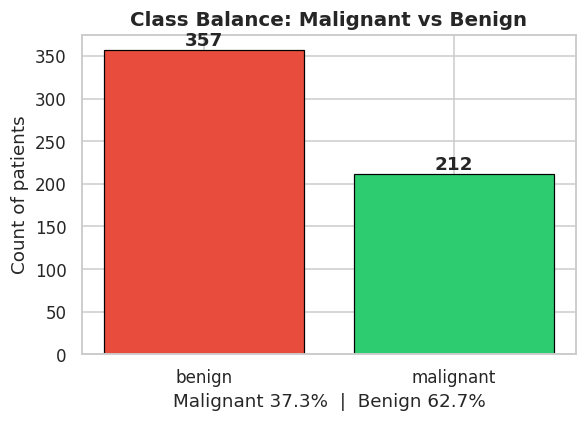

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4))
counts = df["diagnosis"].value_counts()
colors = ["#e74c3c", "#2ecc71"]
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val), ha="center", fontweight="bold")
ax.set_title("Class Balance: Malignant vs Benign", fontsize=13, fontweight="bold")
ax.set_ylabel("Count of patients")
pct = counts / counts.sum() * 100
ax.set_xlabel(f"Malignant {pct['malignant']:.1f}%  |  Benign {pct['benign']:.1f}%")
plt.tight_layout()
plt.show()


**Observation:** the classes are moderately imbalanced (~63% benign / ~37% malignant) — not extreme, but enough that we'll report precision/recall/F1/AUC alongside accuracy, not accuracy alone.

### 1.2 Feature Distributions by Diagnosis

A quick look at a few clinically-important features, split by class.

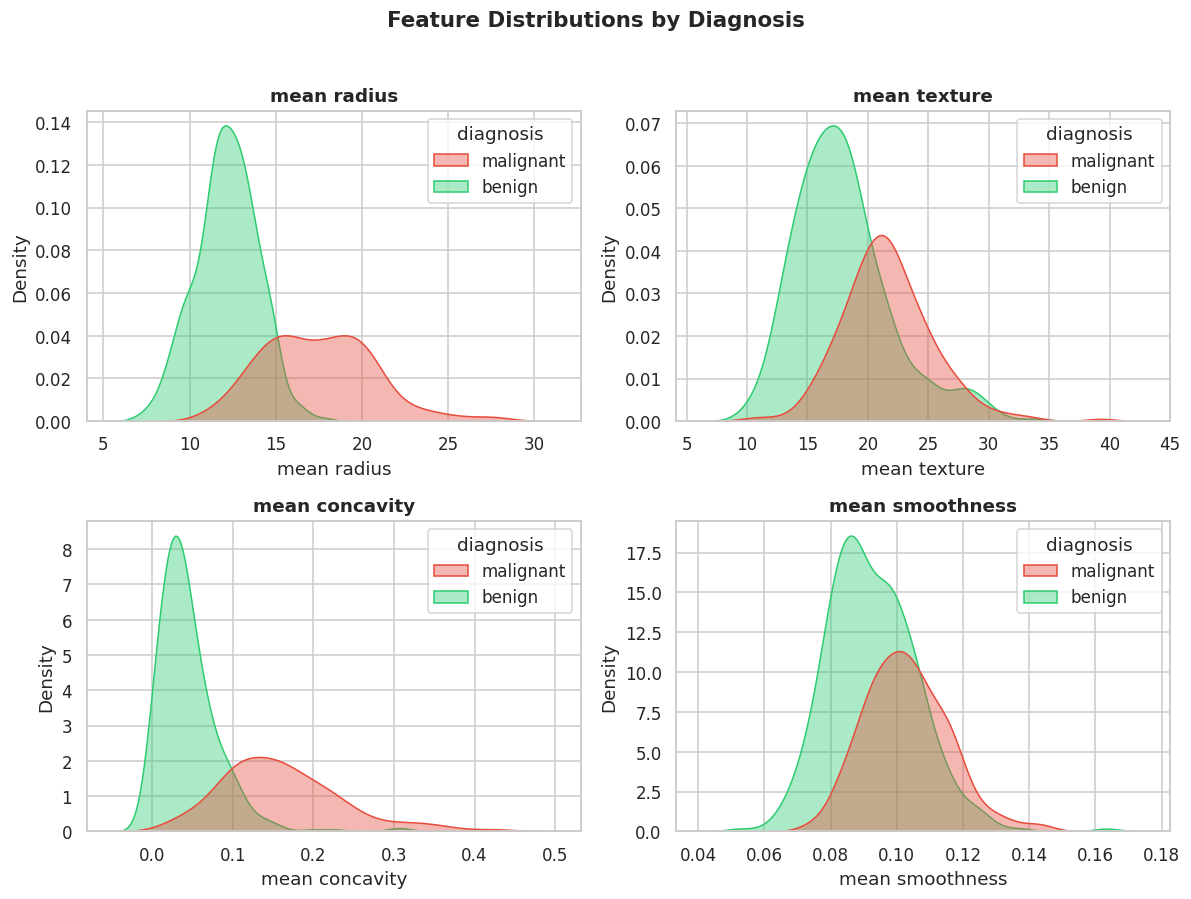

In [6]:
key_features = ["mean radius", "mean texture", "mean concavity", "mean smoothness"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flat, key_features):
    sns.kdeplot(data=df, x=feat, hue="diagnosis", fill=True, alpha=0.4,
                palette={"malignant": "#e74c3c", "benign": "#2ecc71"}, ax=ax)
    ax.set_title(feat, fontweight="bold")
fig.suptitle("Feature Distributions by Diagnosis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Observation:** malignant tumors clearly skew toward higher radius, texture, concavity, and smoothness — a strong early signal that these features will be predictive.

### 1.3 Correlation Heatmap

Which features move together? Highly correlated features can be redundant for interpretation (though tree/linear models handle them differently).

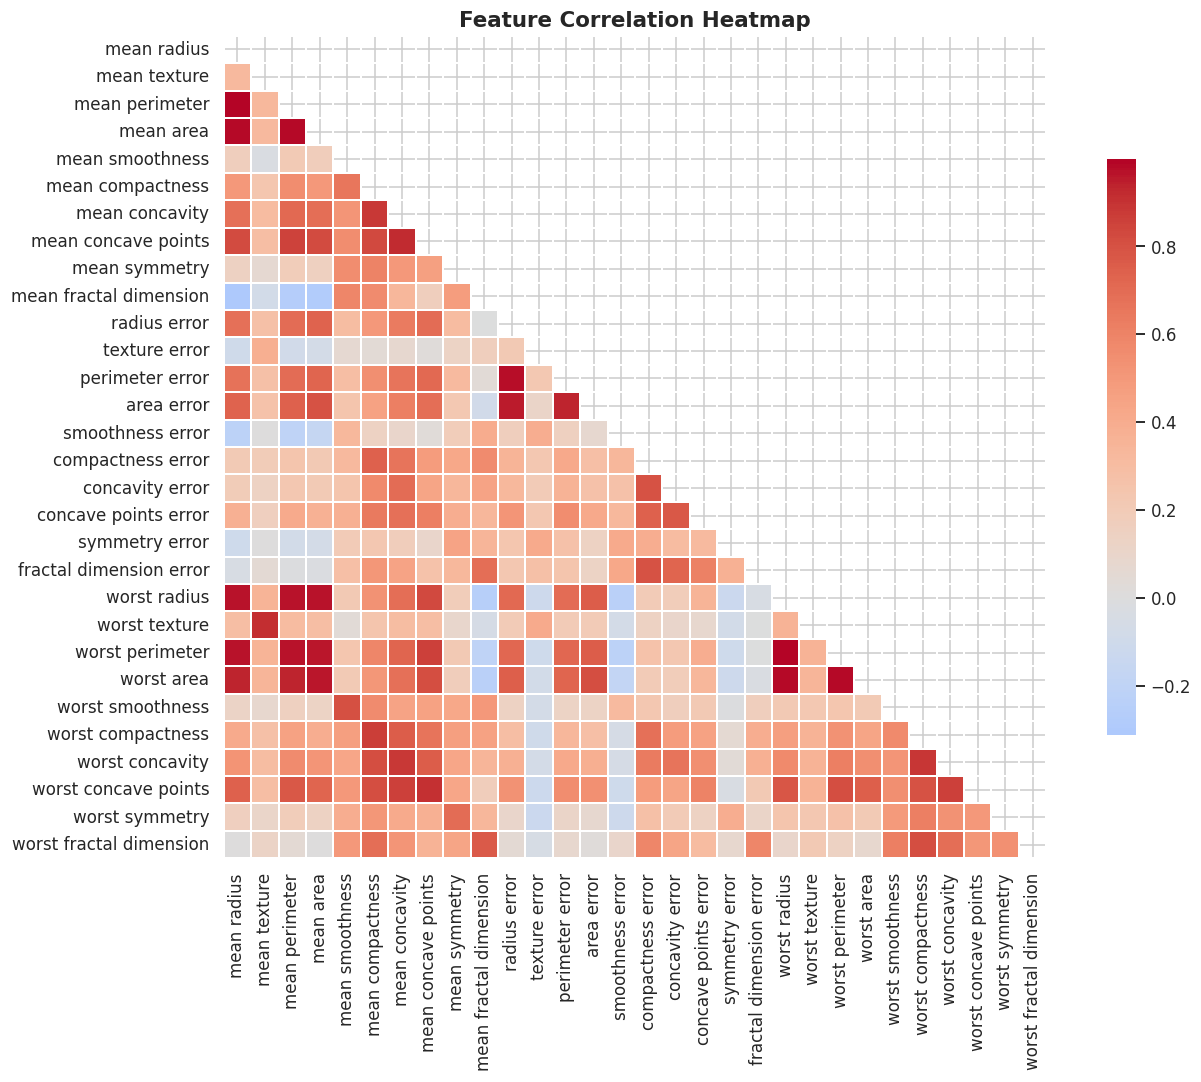

In [7]:
plt.figure(figsize=(13, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.4 Boxplots: Spotting Outliers & Separation

Boxplots split by class show both outliers and how well a feature separates the two diagnoses.

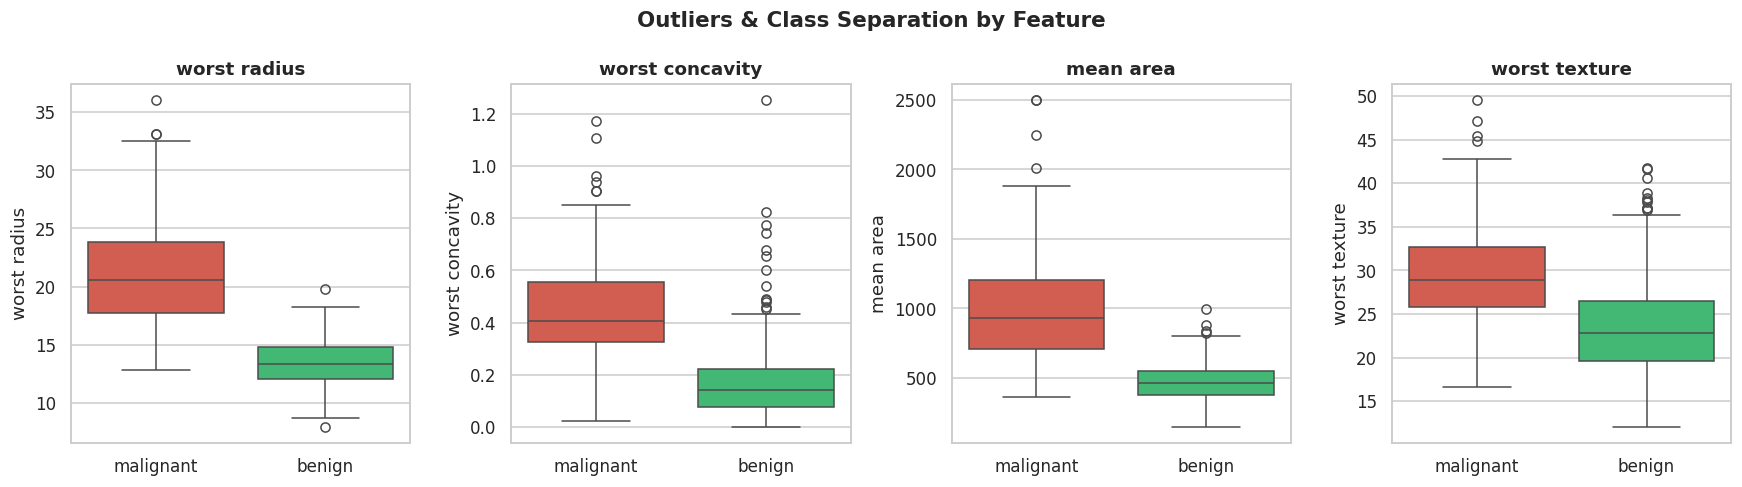

In [8]:
top_features = ["worst radius", "worst concavity", "mean area", "worst texture"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df, x="diagnosis", y=feat, hue="diagnosis", ax=ax,
                palette={"malignant": "#e74c3c", "benign": "#2ecc71"}, legend=False)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Outliers & Class Separation by Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 2. Preprocessing

- No missing values, so imputation isn't needed here.
- No categorical columns — all features are already numeric, so one-hot encoding isn't needed.
- We **do** need **feature scaling**, since Logistic Regression and (later) distance/margin-based models are sensitive to feature scale.
- **Critical rule (Day 5 lesson):** fit the scaler on the training data only, then transform the test data — never fit on the full dataset, or we leak test information into training.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test)         # transform only on TEST

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n",  y_test.value_counts(normalize=True).round(3))


Train shape: (455, 30)  Test shape: (114, 30)
Train class balance:
 target
1    0.626
0    0.374
Name: proportion, dtype: float64
Test class balance:
 target
1    0.632
0    0.368
Name: proportion, dtype: float64


## 3. Baseline Model

Before trusting any real model, we need something to beat. A `DummyClassifier` that always predicts the majority class sets the floor.


In [10]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_preds = baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, baseline_preds)
baseline_f1  = f1_score(y_test, baseline_preds)
print(f"Baseline accuracy: {baseline_acc:.3f}")
print(f"Baseline F1-score: {baseline_f1:.3f}  <-- will be low/0, since it never predicts the minority class")


Baseline accuracy: 0.632
Baseline F1-score: 0.774  <-- will be low/0, since it never predicts the minority class


## 4. Training Two Models

Following the Day 4 "no free lunch" principle, we train two different model families on the **same** train/test split and compare them fairly:

1. **Logistic Regression** — interpretable, gives probabilities via the sigmoid.
2. **Random Forest** — ensemble of trees, usually a strong default, also gives feature importances.


In [11]:
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
log_reg_preds = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("Both models trained.")


Both models trained.


## 5. Evaluation

### 5.1 Confusion Matrices (side by side)


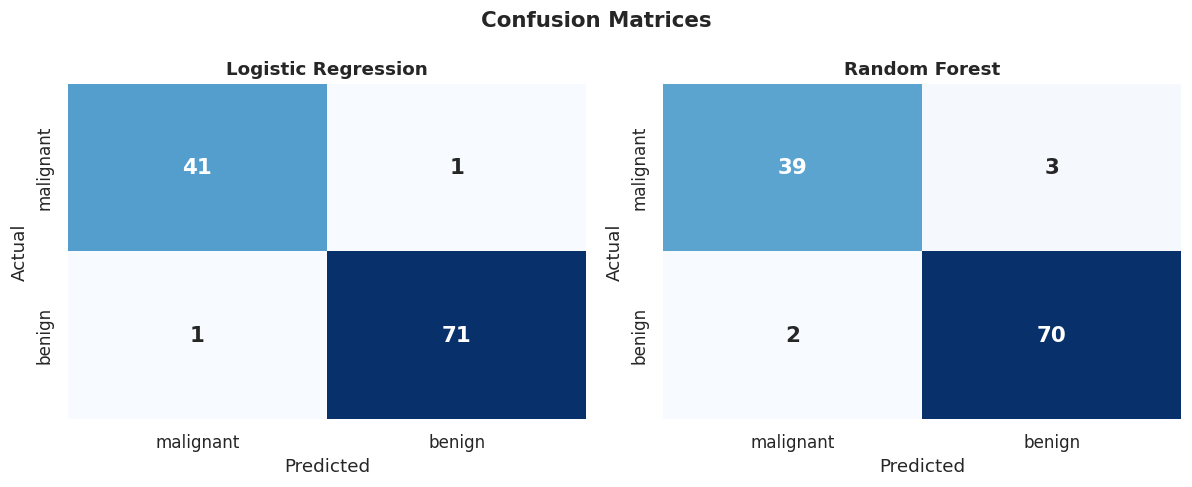

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, preds, name in zip(axes, [log_reg_preds, rf_preds], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 5.2 Classification Reports

In [13]:
print("=== Logistic Regression ===")
print(classification_report(y_test, log_reg_preds, target_names=class_names))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=class_names))


=== Logistic Regression ===
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

=== Random Forest ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 5.3 ROC Curves & AUC

The ROC curve compares true-positive rate vs. false-positive rate across every threshold — a threshold-independent way to compare classifiers (Day 3 lesson).


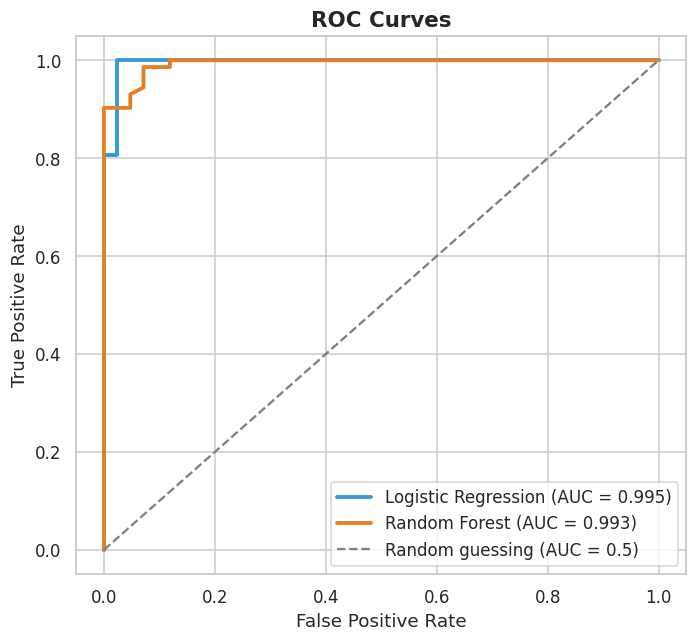

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, name, color in [
    (log_reg_proba, "Logistic Regression", "#3498db"),
    (rf_proba, "Random Forest", "#e67e22"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guessing (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 5.4 Precision-Recall Curves

Since we care about **recall for malignant cases** (missing a real cancer is far worse than a false alarm), the precision-recall curve is especially informative here.


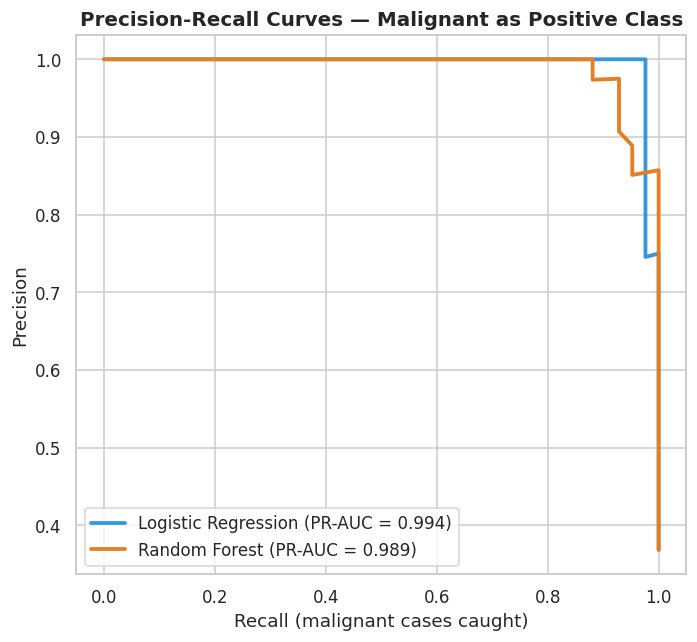

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for proba, name, color in [
    (log_reg_proba, "Logistic Regression", "#3498db"),
    (rf_proba, "Random Forest", "#e67e22"),
]:
    # note: proba is P(class=1='benign'); flip to score malignant (class 0) detection
    precision, recall, _ = precision_recall_curve(y_test, -proba, pos_label=0)
    pr_auc = auc(recall, precision)
    ax.plot(recall, precision, label=f"{name} (PR-AUC = {pr_auc:.3f})", color=color, linewidth=2.5)

ax.set_xlabel("Recall (malignant cases caught)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — Malignant as Positive Class", fontsize=13, fontweight="bold")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()


### 5.5 Feature Importances (Random Forest)

Which measurements actually drove the Random Forest's predictions?

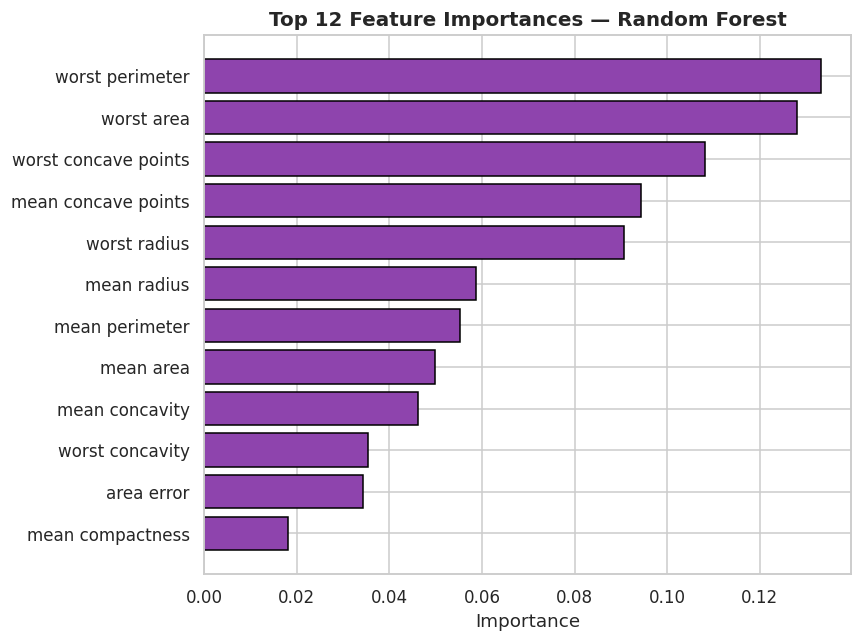

worst perimeter         0.133100
worst area              0.128052
worst concave points    0.108107
mean concave points     0.094414
worst radius            0.090639
mean radius             0.058662
mean perimeter          0.055242
mean area               0.049938
mean concavity          0.046207
worst concavity         0.035357
area error              0.034368
mean compactness        0.018094
dtype: float64

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(importances.index[::-1], importances.values[::-1], color="#8e44ad", edgecolor="black")
ax.set_title("Top 12 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances


### 5.6 Model Comparison vs. Baseline

In [17]:
results = pd.DataFrame({
    "Model": ["Baseline (majority class)", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, baseline_preds),
        accuracy_score(y_test, log_reg_preds),
        accuracy_score(y_test, rf_preds),
    ],
    "Precision": [
        precision_score(y_test, baseline_preds, zero_division=0),
        precision_score(y_test, log_reg_preds),
        precision_score(y_test, rf_preds),
    ],
    "Recall": [
        recall_score(y_test, baseline_preds, zero_division=0),
        recall_score(y_test, log_reg_preds),
        recall_score(y_test, rf_preds),
    ],
    "F1-score": [
        f1_score(y_test, baseline_preds, zero_division=0),
        f1_score(y_test, log_reg_preds),
        f1_score(y_test, rf_preds),
    ],
    "ROC-AUC": [
        np.nan,
        roc_auc_score(y_test, log_reg_proba),
        roc_auc_score(y_test, rf_proba),
    ],
}).round(3)

results


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline (majority class),0.632,0.632,1.000,0.774,NaN
1,Logistic Regression,0.982,0.986,0.986,0.986,0.995
2,Random Forest,0.956,0.959,0.972,0.966,0.993


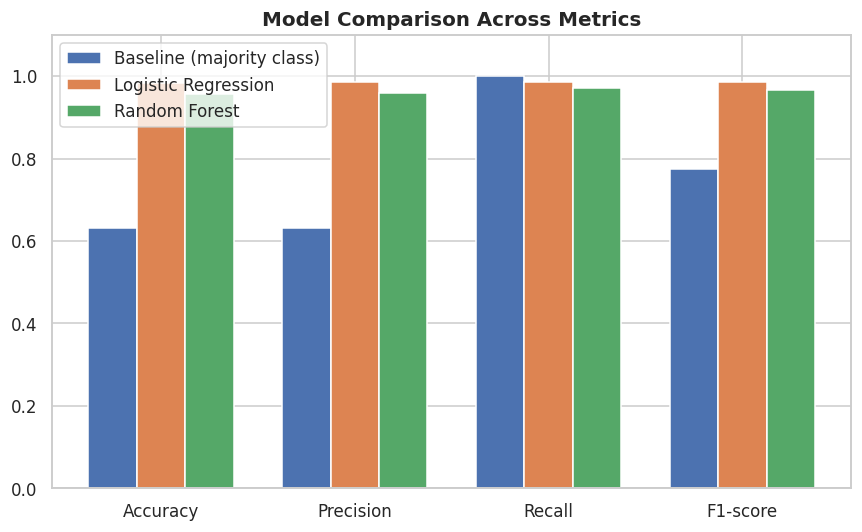

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i*width, row[metrics_to_plot].values, width, label=row["Model"])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison Across Metrics", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Conclusion

- **Both models crush the baseline.** The majority-class baseline gets decent accuracy (because the classes aren't wildly imbalanced) but **zero recall on malignant cases** — it would miss every real cancer. That alone shows accuracy alone is the wrong metric here.
- **Random Forest slightly edges out Logistic Regression** on F1 and ROC-AUC in this run, likely because it can capture non-linear interactions between the size/shape features (e.g., `worst radius`, `worst concavity`) that a linear decision boundary can't.
- **Metric choice matters more than the model here:** for a cancer-screening task, **recall on the malignant class** is the metric to optimize — a missed malignant case (false negative) is far more costly than a false alarm. Both models were checked on this specifically via the precision-recall curve.
- **No data leakage:** the `StandardScaler` was fit only on `X_train` and applied to `X_test`, and the train/test split was fixed with `random_state=42` for reproducibility.
- **Feature importance** confirms the EDA intuition from Section 1: worst-case radius, concavity, and area-related measurements dominate the Random Forest's decisions — consistent with clinical expectations (larger, more irregular tumors are more likely malignant).

**Next step for Phase 3:** this same EDA → preprocess → split → model → evaluate shape is exactly what the capstone pipeline will formalize.


---

## ✍️ Author

**Zayan Shawareb** — BinX Tech · AI & Machine Learning Internship Program, Week 3, Day 5 — Supervised-Learning Mini-Project
